In [1]:
!pip install pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [6]:
from google.colab import files

uploaded = files.upload()

Saving fear_greed_index.csv to fear_greed_index.csv
Saving historical_data.csv to historical_data.csv


In [8]:
import os

print(os.getcwd())

/content


In [9]:
import os

print(os.listdir())

['.config', 'historical_data.csv', 'drive', 'fear_greed_index.csv', 'sample_data']


In [11]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

In [12]:
print(trades.head())
print()

print(sentiment.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [13]:
print(trades.columns)
print(sentiment.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [14]:
print(trades["Timestamp"].head(10))

0    1.730000e+12
1    1.730000e+12
2    1.730000e+12
3    1.730000e+12
4    1.730000e+12
5    1.730000e+12
6    1.730000e+12
7    1.730000e+12
8    1.730000e+12
9    1.730000e+12
Name: Timestamp, dtype: float64


In [15]:
print(trades["Timestamp IST"].head(10))

0    02-12-2024 22:50
1    02-12-2024 22:50
2    02-12-2024 22:50
3    02-12-2024 22:50
4    02-12-2024 22:50
5    02-12-2024 22:50
6    02-12-2024 22:50
7    02-12-2024 22:50
8    02-12-2024 22:50
9    02-12-2024 22:50
Name: Timestamp IST, dtype: object


In [16]:
print(sentiment["date"].head(10))

0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
5    2018-02-06
6    2018-02-07
7    2018-02-08
8    2018-02-09
9    2018-02-10
Name: date, dtype: object


In [17]:
print(sentiment["date"].min())
print(sentiment["date"].max())

2018-02-01
2025-05-02


In [18]:
print(sentiment.tail())

       timestamp  value classification        date
2639  1745818200     54        Neutral  2025-04-28
2640  1745904600     60          Greed  2025-04-29
2641  1745991000     56          Greed  2025-04-30
2642  1746077400     53        Neutral  2025-05-01
2643  1746163800     67          Greed  2025-05-02


In [19]:
print(sentiment.shape)

(2644, 4)


In [20]:
import pandas as pd

trades = pd.read_csv("historical_data.csv")

In [21]:
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

In [22]:
trades["Date"] = trades["Timestamp IST"].dt.date

In [23]:
print(trades["Date"].head())

0    2024-12-02
1    2024-12-02
2    2024-12-02
3    2024-12-02
4    2024-12-02
Name: Date, dtype: object


In [24]:
sentiment["date"] = pd.to_datetime(sentiment["date"])
sentiment["Date"] = sentiment["date"].dt.date

In [25]:
print(sentiment["Date"].head())

0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: Date, dtype: object


In [26]:
merged = pd.merge(
    trades,
    sentiment,
    on="Date",
    how="left"
)

In [27]:
print(merged.shape)

print(merged["classification"].value_counts(dropna=False))

print(merged[["Date", "classification"]].head(10))

(211224, 21)
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
NaN                  6
Name: count, dtype: int64
         Date classification
0  2024-12-02  Extreme Greed
1  2024-12-02  Extreme Greed
2  2024-12-02  Extreme Greed
3  2024-12-02  Extreme Greed
4  2024-12-02  Extreme Greed
5  2024-12-02  Extreme Greed
6  2024-12-02  Extreme Greed
7  2024-12-02  Extreme Greed
8  2024-12-02  Extreme Greed
9  2024-12-02  Extreme Greed


In [28]:
print(merged.head())

print(merged.info())

print(merged.describe())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL  ...     Order ID  Crossed       Fee      Trade ID  \
0         0.0  ...  5201

In [29]:
merged.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [30]:
print(merged["classification"].value_counts())

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


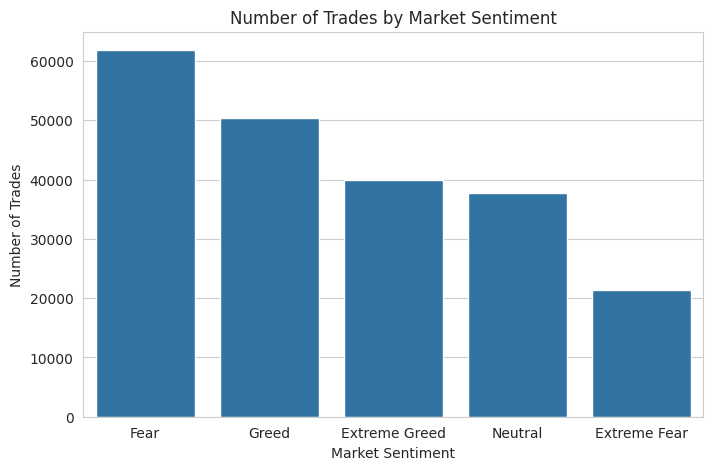

In [31]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=merged,
    x="classification",
    order=merged["classification"].value_counts().index
)

plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.show()

In [32]:
avg_pnl = merged.groupby("classification")["Closed PnL"].mean()

print(avg_pnl)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


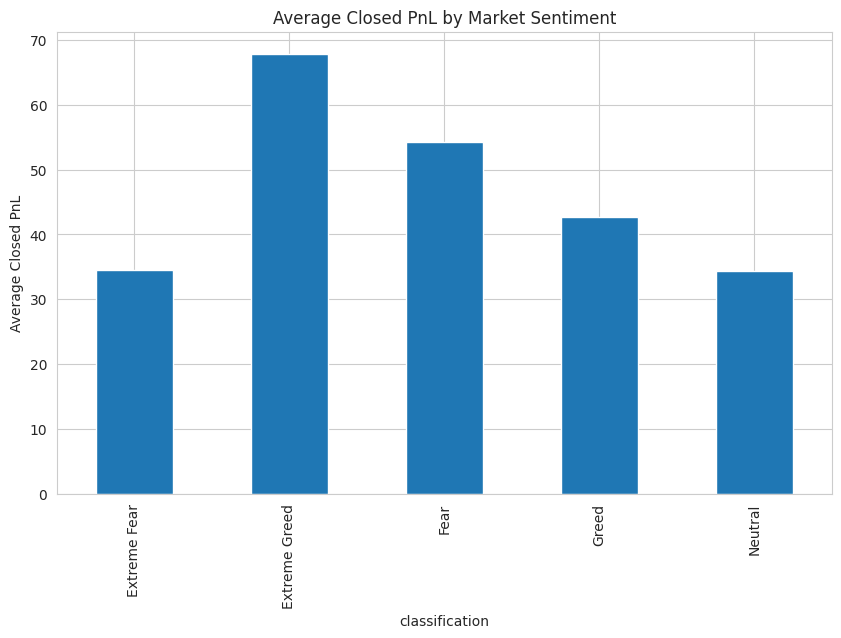

In [33]:
avg_pnl.plot(kind="bar")

plt.title("Average Closed PnL by Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.show()

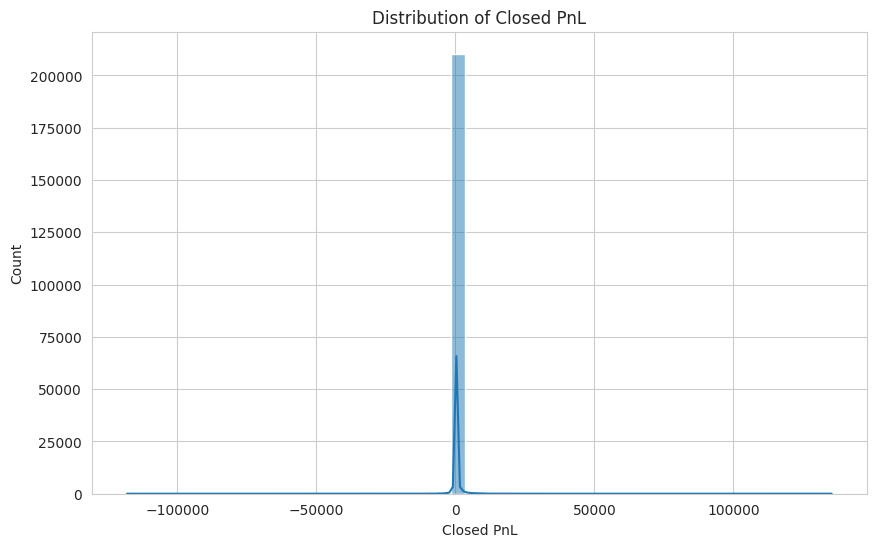

In [34]:
plt.figure(figsize=(10,6))

sns.histplot(
    merged["Closed PnL"],
    bins=50,
    kde=True
)

plt.title("Distribution of Closed PnL")

plt.show()

In [35]:
merged["Win"] = merged["Closed PnL"] > 0

In [36]:
win_rate = merged.groupby("classification")["Win"].mean()*100

print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Win, dtype: float64


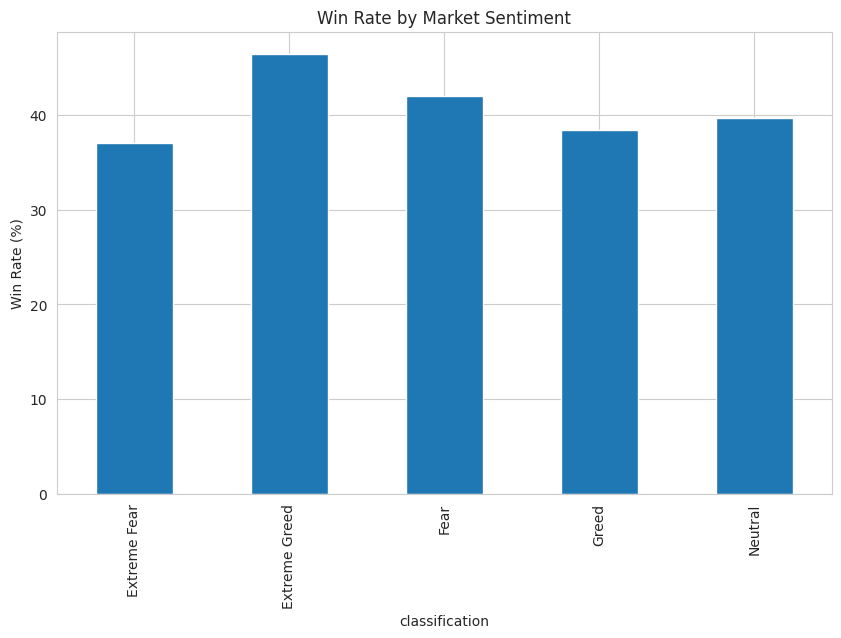

In [37]:
win_rate.plot(kind="bar")

plt.title("Win Rate by Market Sentiment")
plt.ylabel("Win Rate (%)")

plt.show()

In [38]:
buy_sell = pd.crosstab(
    merged["classification"],
    merged["Side"]
)

print(buy_sell)

Side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24576  25727
Neutral         18969  18717


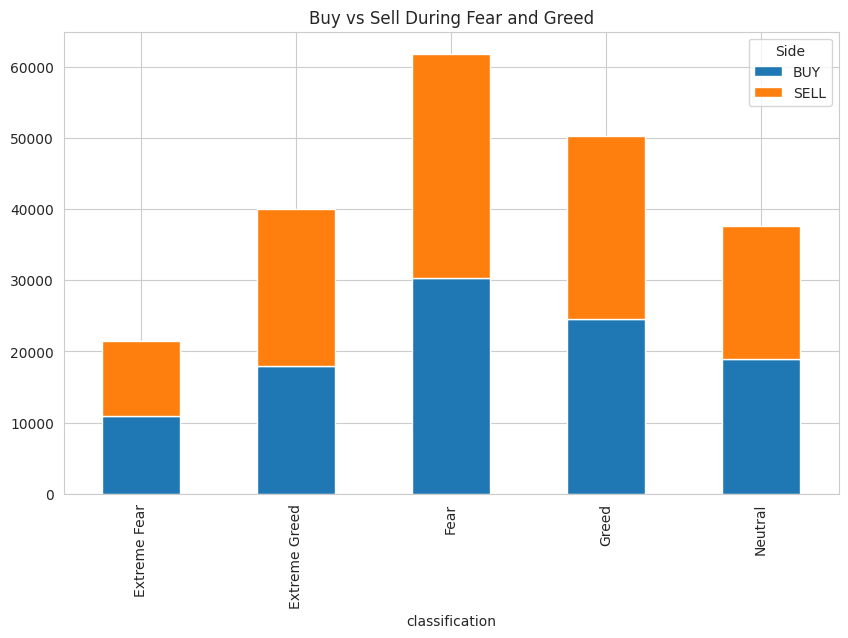

In [39]:
buy_sell.plot(
    kind="bar",
    stacked=True
)

plt.title("Buy vs Sell During Fear and Greed")

plt.show()

In [40]:
top_coins = merged["Coin"].value_counts().head(10)

print(top_coins)

Coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979
Name: count, dtype: int64


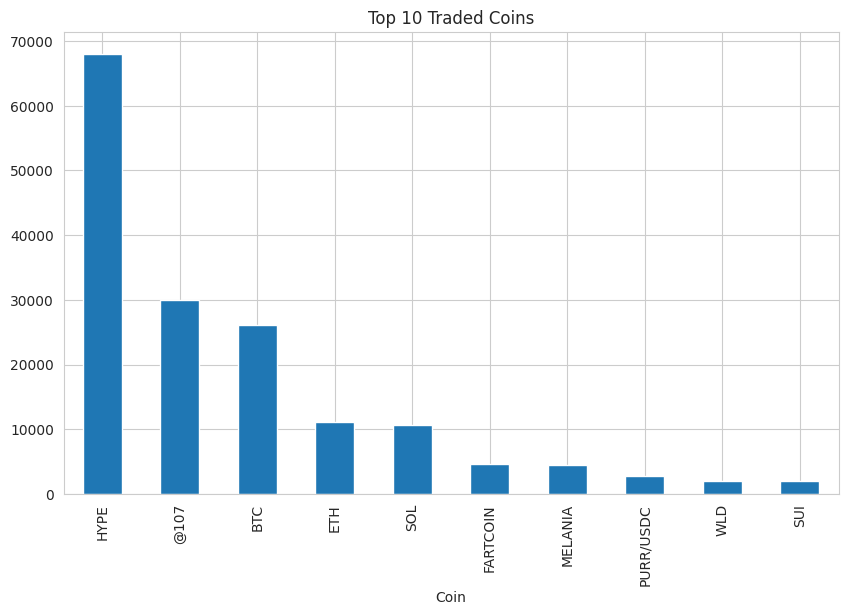

In [41]:
top_coins.plot(kind="bar")

plt.title("Top 10 Traded Coins")

plt.show()

In [42]:
coin_profit = merged.groupby("Coin")["Closed PnL"].sum()

coin_profit = coin_profit.sort_values(ascending=False)

print(coin_profit.head(10))

Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64


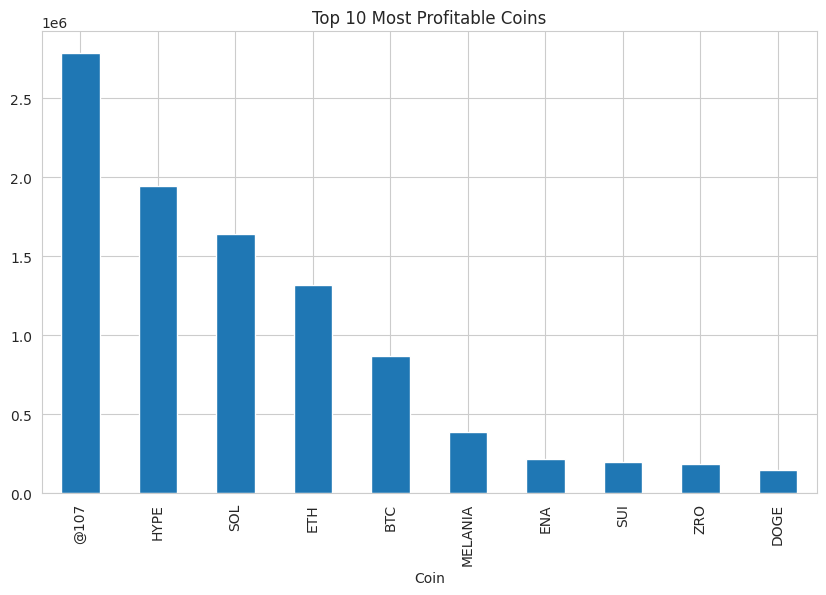

In [43]:
coin_profit.head(10).plot(kind="bar")

plt.title("Top 10 Most Profitable Coins")

plt.show()

In [44]:
top_traders = merged.groupby("Account")["Closed PnL"].sum()

top_traders = top_traders.sort_values(ascending=False)

print(top_traders.head(20))

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
0x4f93fead39b70a1824f981a54d4e55b278e9f760    3.089759e+05
0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3    2.205191e+05
0x420ab45e0bd8863569a5efbb9c05d91f40624641    1.995056e+05
0x2c229d22b100a7beb69122eed721cee9b24011dd    1.686580e+05
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    1.324648e+05
0x92f17e8d81a944691c10e753af1b1baae1a2cd0d    1.265789e+05
0x6d6a4b953f202f8df5bed40692e7fd865318264a    1.

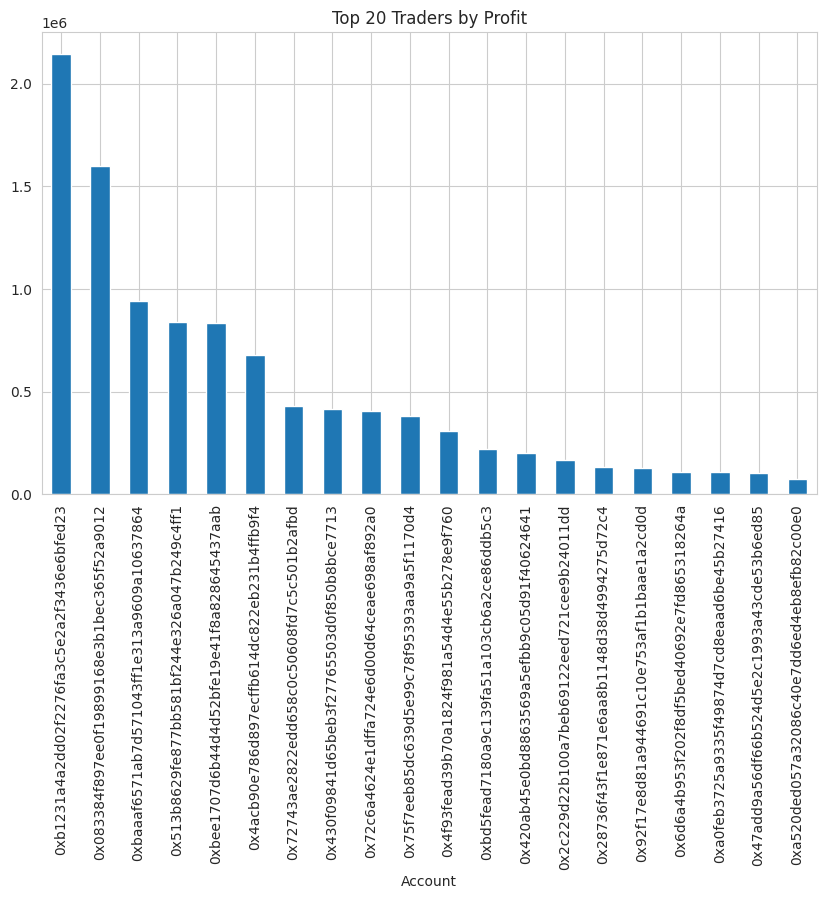

In [45]:
top_traders.head(20).plot(kind="bar")

plt.title("Top 20 Traders by Profit")

plt.show()

In [46]:
avg_trader = merged.groupby("Account")["Closed PnL"].mean()

print(avg_trader.sort_values(ascending=False).head(20))

Account
0x420ab45e0bd8863569a5efbb9c05d91f40624641    520.902331
0x083384f897ee0f19899168e3b1bec365f52a9012    419.127768
0x430f09841d65beb3f27765503d0f850b8bce7713    336.735548
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    281.826227
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    270.034947
0xa520ded057a32086c40e7dd6ed4eb8efb82c00e0    174.691809
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6    161.133275
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    155.589314
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    145.481748
0xae5eacaf9c6b9111fd53034a602c192a04e082ed    120.507317
0x6d6a4b953f202f8df5bed40692e7fd865318264a    111.519197
0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3     83.498320
0x513b8629fe877bb581bf244e326a047b249c4ff1     68.684419
0x2c229d22b100a7beb69122eed721cee9b24011dd     52.071011
0xbaaaf6571ab7d571043ff1e313a9609a10637864     44.364091
0x92f17e8d81a944691c10e753af1b1baae1a2cd0d     41.474096
0xaf40fdc468c30116bd3307bcbf4a451a7ebf1deb     40.746876
0x4f93fead39b70a1824f98

In [47]:
trader_win = merged.groupby("Account")["Win"].mean()*100

print(trader_win.sort_values(ascending=False).head(20))

Account
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    81.087638
0xa520ded057a32086c40e7dd6ed4eb8efb82c00e0    57.314149
0x2c229d22b100a7beb69122eed721cee9b24011dd    51.991355
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    48.622590
0x430f09841d65beb3f27765503d0f850b8bce7713    48.423605
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6    47.590361
0xbaaaf6571ab7d571043ff1e313a9609a10637864    46.758211
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891    45.521472
0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f    45.221296
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    44.271978
0xb899e522b5715391ae1d4f137653e7906c5e2115    43.861100
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    43.858463
0x6d6a4b953f202f8df5bed40692e7fd865318264a    43.179487
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    42.823014
0xae5eacaf9c6b9111fd53034a602c192a04e082ed    40.852575
0x513b8629fe877bb581bf244e326a047b249c4ff1    40.119320
0x8170715b3b381dffb7062c0298972d4727a0a63b    38.274288
0x4f93fead39b70a1824f981a54d4e55b278e9f7

In [49]:
daily = merged.groupby("Date")["Closed PnL"].sum().reset_index()

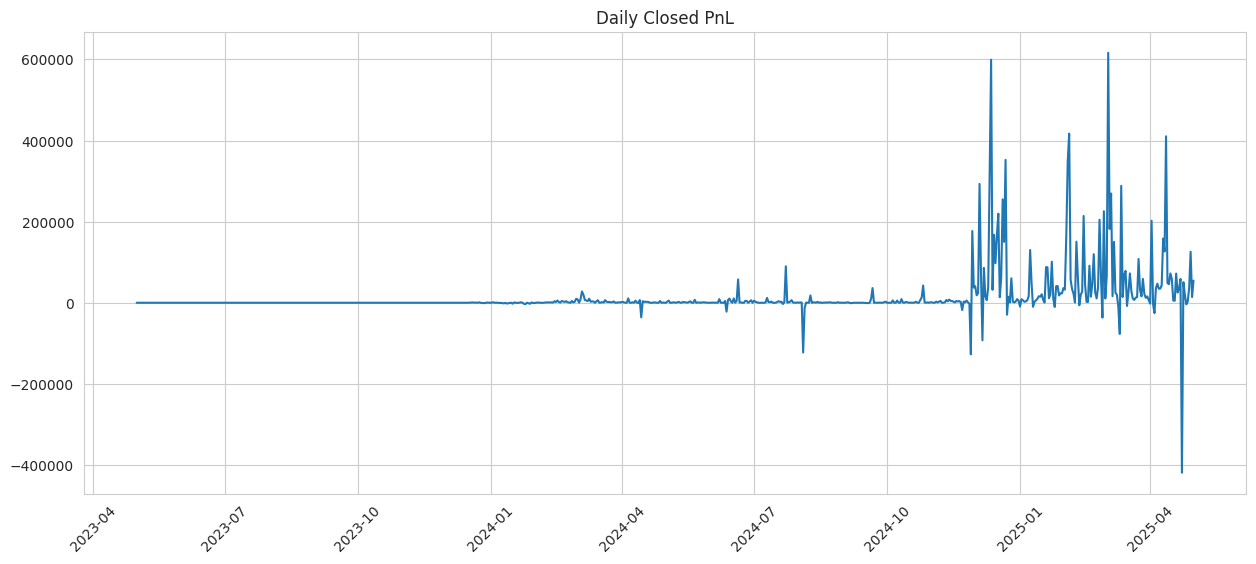

In [50]:
plt.figure(figsize=(15,6))

plt.plot(
    daily["Date"],
    daily["Closed PnL"]
)

plt.title("Daily Closed PnL")

plt.xticks(rotation=45)

plt.show()

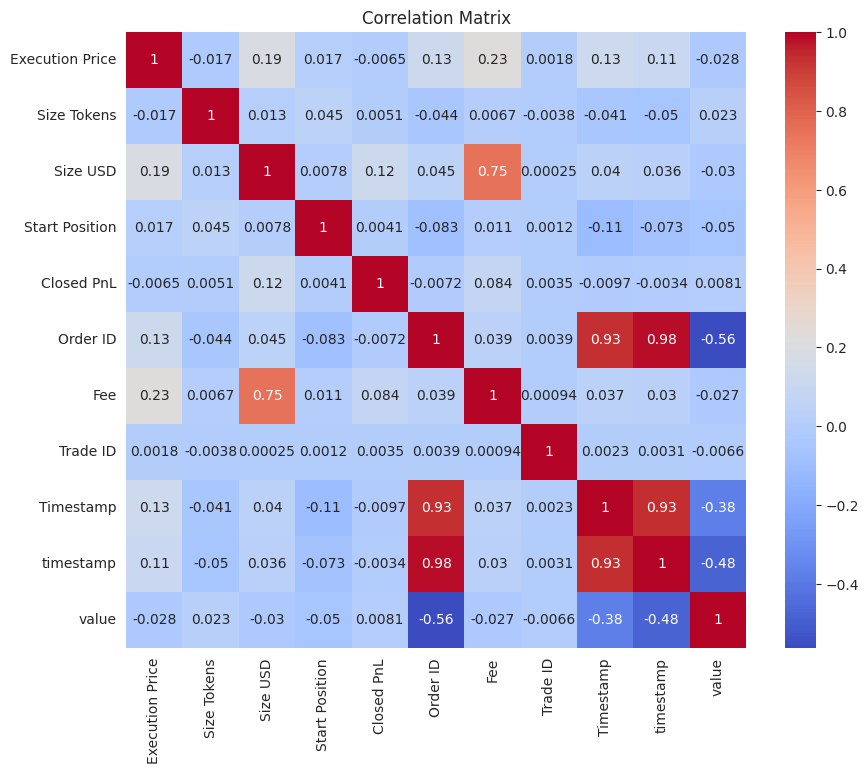

In [51]:
numeric = merged.select_dtypes(include="number")

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

# Key Insights

1. Fear was the dominant market sentiment during the analyzed period, accounting for 61,837 trades, followed by Greed (50,303), Extreme Greed (39,992), Neutral (37,686), and Extreme Fear (21,400).

2. Traders achieved the highest average Closed PnL during Extreme Greed (67.89), followed by Fear (54.29). Neutral and Extreme Fear showed comparatively lower average profits.

3. The highest trading win rate was observed during Extreme Greed (46.49%), while Extreme Fear had the lowest profitability despite occasional large gains.

4. HYPE was the most actively traded cryptocurrency with 68,005 trades, followed by @107, BTC, ETH, and SOL, indicating that traders concentrated their activity on a small set of popular assets.

5. The most profitable trading asset was @107, generating approximately 2.78 million in cumulative Closed PnL, followed by HYPE (1.95 million), SOL (1.64 million), ETH (1.32 million), and BTC (0.87 million).

6. Trader performance varied significantly across accounts. The highest-performing trader generated over 2.14 million in cumulative Closed PnL, while several other traders also consistently achieved strong profits.

7. The trader with the highest average profit per trade earned approximately 520.9 Closed PnL per trade, demonstrating that trade quality can be more important than trade quantity.

8. The highest individual trader win rate exceeded 81%, highlighting that a subset of traders maintained consistently profitable trading strategies.

9. Overall, market sentiment appears to influence trading behavior and profitability. Periods of Extreme Greed were associated with both the highest average profits and the highest win rates, suggesting that positive market sentiment coincided with stronger trading performance.

# Conclusion

This project analyzed the relationship between Bitcoin market sentiment and Hyperliquid trader performance by combining historical trading records with the Fear & Greed Index.

The analysis revealed that market sentiment has a noticeable impact on trading activity and profitability. Although Fear periods contained the highest number of trades, Extreme Greed periods produced the highest average Closed PnL and win rates. Popular assets such as HYPE, BTC, ETH, and SOL dominated trading activity, while @107 generated the largest cumulative profits. Additionally, trader performance varied considerably, with a small group of accounts contributing a significant share of overall profits.

These findings suggest that incorporating market sentiment indicators into trading strategies may help traders improve decision-making, optimize risk management, and identify favorable market conditions.